# Analyse network results for sector-coupled PyPSA-Earth
This notebook processes the latest optimization data specified in the config.yaml file and the network .nc file. It generates comprehensive plots and summaries to visualize the results.

Sources: 
- Statistics module: https://pypsa.readthedocs.io/en/latest/examples/statistics.html
- Templates and colors: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/network_analysis.ipynb

File is needed:
* PyPSA network file (.nc) includes the heating, transprot, and electricity demand information.

## Import packages

In [1]:
import yaml
import pypsa
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import os
import warnings

## Path settings
This section reads the config parameters from your config.yaml file and automatically reads the output of the optimization with those settings

In [2]:
warnings.simplefilter(action='ignore', category=FutureWarning)
# change current directory to parent folder
if not os.path.isdir("pypsa-earth"):
    os.chdir("../..")

PARENT = os.path.realpath("pypsa-earth/") + "/"
# Specify config name
CONFIG = "config-dz-sec-3H-NoCo2Sequ+NoBiomass"
config = yaml.safe_load(open(PARENT + "own-configs/" + CONFIG + ".yaml"))

In [3]:
run_name = config["run"]["name"]
run_sector_name = config["run"]["sector_name"]                          
simpl = config["scenario"]["simpl"]    
clust = config["scenario"]["clusters"]   
ll = config["scenario"]["ll"]             
load_scale = config["load_options"]["scale"]               
opts = config["scenario"]["opts"]       
sopts = config["scenario"]["sopts"]              
planning = config["scenario"]["planning_horizons"]        
discountrate = config["costs"]["discountrate"]                
demand = config["scenario"]["demand"]                  
export_value = config["export"]["h2export"]                  

# Process each setting into a string representation 
simpl_str = "_".join(map(str, simpl))   
clust_str = "_".join(map(str, clust))    
ll_str = "l" + "_".join(map(str, ll))           
scale_str = f"lc{load_scale}"                           
opts_str = "_".join(map(str, opts))    
sopts_str = "_".join(map(str, sopts))                 
planning_str = "_".join(map(str, planning))               
dr_str = "_".join(map(str, discountrate))             
demand_str = "_".join(map(str, demand))                    
export_str = "_".join(map(str, export_value)) + "export"   

nc_file_name = (
    f"elec_s_{clust_str}_ec_{ll_str}_{opts_str}_{sopts_str}_"
    f"{planning_str}_{dr_str}_{demand_str}_{export_str}.nc"
)

### Analysis Network Setup

In [4]:
# scenario_subpath = f"{run_name}/" if run_name else ""
scenario_subpath = f"{run_sector_name}/" if run_sector_name else ""
results_path = PARENT + f"results/{run_sector_name}/postnetworks/{nc_file_name}"
n = pypsa.Network(results_path)

Index(['H2 pipeline DZA.10_1 -> DZA.45_1 repurposed',
       'H2 pipeline DZA.12_1 -> DZA.13_1 repurposed',
       'H2 pipeline DZA.15_1 -> DZA.39_1 repurposed',
       'H2 pipeline DZA.16_1 -> DZA.12_1 repurposed',
       'H2 pipeline DZA.16_1 -> DZA.28_1 repurposed',
       'H2 pipeline DZA.16_1 -> DZA.43_1 repurposed',
       'H2 pipeline DZA.16_1 -> DZA.9_1 repurposed',
       'H2 pipeline DZA.17_1 -> DZA.1_1 repurposed',
       'H2 pipeline DZA.17_1 -> DZA.31_1 repurposed',
       'H2 pipeline DZA.18_1 -> DZA.24_1 repurposed',
       ...
       'H2 pipeline DZA.43_1 -> DZA.35_1', 'H2 pipeline DZA.43_1 -> DZA.36_1',
       'H2 pipeline DZA.48_1 -> DZA.3_1', 'H2 pipeline DZA.5_1 -> DZA.19_1',
       'H2 pipeline DZA.6_1 -> DZA.26_1', 'H2 pipeline DZA.6_1 -> DZA.29_1',
       'H2 pipeline DZA.6_1 -> DZA.37_1', 'H2 pipeline DZA.9_1 -> DZA.18_1',
       'H2 pipeline DZA.9_1 -> DZA.26_1', 'H2 pipeline DZA.9_1 -> DZA.6_1'],
      dtype='object', name='name', length=108)
Index(['H2 pipeli

## Data import check

List number of components by type

In [5]:
for c in n.iterate_components(list(n.components.keys())[2:]):
    print("Component '{}' has {} entries".format(c.name,len(c.df)))

Component 'Bus' has 1132 entries
Component 'Carrier' has 38 entries
Component 'GlobalConstraint' has 1 entries
Component 'Line' has 97 entries
Component 'LineType' has 34 entries
Component 'TransformerType' has 14 entries
Component 'Link' has 3128 entries
Component 'Load' has 1421 entries
Component 'Generator' has 1750 entries
Component 'StorageUnit' has 1 entries
Component 'Store' has 755 entries


List the snapshots of the PyPSA network

In [6]:
print(n.snapshots)
print(f"Time steps: " + str(len(n.snapshots)))

DatetimeIndex(['2013-01-01 00:00:00', '2013-01-01 03:00:00',
               '2013-01-01 06:00:00', '2013-01-01 09:00:00',
               '2013-01-01 12:00:00', '2013-01-01 15:00:00',
               '2013-01-01 18:00:00', '2013-01-01 21:00:00',
               '2013-01-02 00:00:00', '2013-01-02 03:00:00',
               ...
               '2013-12-30 18:00:00', '2013-12-30 21:00:00',
               '2013-12-31 00:00:00', '2013-12-31 03:00:00',
               '2013-12-31 06:00:00', '2013-12-31 09:00:00',
               '2013-12-31 12:00:00', '2013-12-31 15:00:00',
               '2013-12-31 18:00:00', '2013-12-31 21:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=2920, freq=None)
Time steps: 2920


## Analyse energy system

### Transport Sector 
The demand of EVs, ICE (internal combustion engine) and FCEV (fuell cell)

In [7]:
load_stats = n.statistics.energy_balance(comps=["Load"], aggregate_time="sum")
transport_stats_GWh = load_stats[load_stats.index.get_level_values('carrier').str.contains(
    'land transport oil(?! emissions)|land transport fuel cell|land transport EV', 
    case=True)]
transport_stats_GWh

component  carrier                   bus_carrier
Load       land transport EV         Li ion        -7.220658e+05
           land transport fuel cell  H2            -1.058774e+07
           land transport oil        oil           -2.005053e+08
Name: objective, dtype: float64

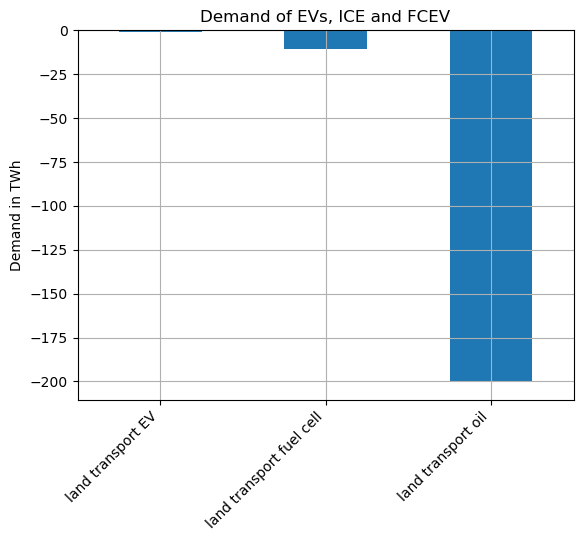

In [8]:
transport_stats_TWh = transport_stats_GWh/1000000

ax = transport_stats_TWh.plot.bar(
    title='Demand of EVs, ICE and FCEV',
    xlabel="",
    ylabel="Demand in TWh"
)

ax.set_xticklabels(transport_stats_GWh.index.get_level_values('carrier'), rotation=45, ha="right")
ax.grid(True) 
plt.show()

### Heating Sector 
The demand of various heating subsectors

In [ ]:
load_stats = n.statistics.energy_balance(comps=["Load"], aggregate_time="sum")
# Wrong naminh (GWh, should be MWh)
heating_stats_GWh = load_stats[load_stats.index.get_level_values('carrier').str.contains('heat', case=False)]
heating_stats_GWh

component  carrier                           bus_carrier                     
Load       residential rural heat            residential rural heat             -2.041518e+05
           residential urban decentral heat  residential urban decentral heat   -8.290895e+05
           urban central heat                urban central heat                 -4.524957e+06
Name: objective, dtype: float64

In [71]:
# Filter links whose carrier contains 'co2'
co2_links = n.links[n.links.carrier.str.contains('co2', case=False, na=False)].index
# Sum the p0 values for these links over all snapshots
(n.links_t.p0[co2_links].sum().sum())*144 / 1e6  # Convert to Mt

22.428222313418757

<AxesSubplot:xlabel='component,carrier,bus_carrier'>

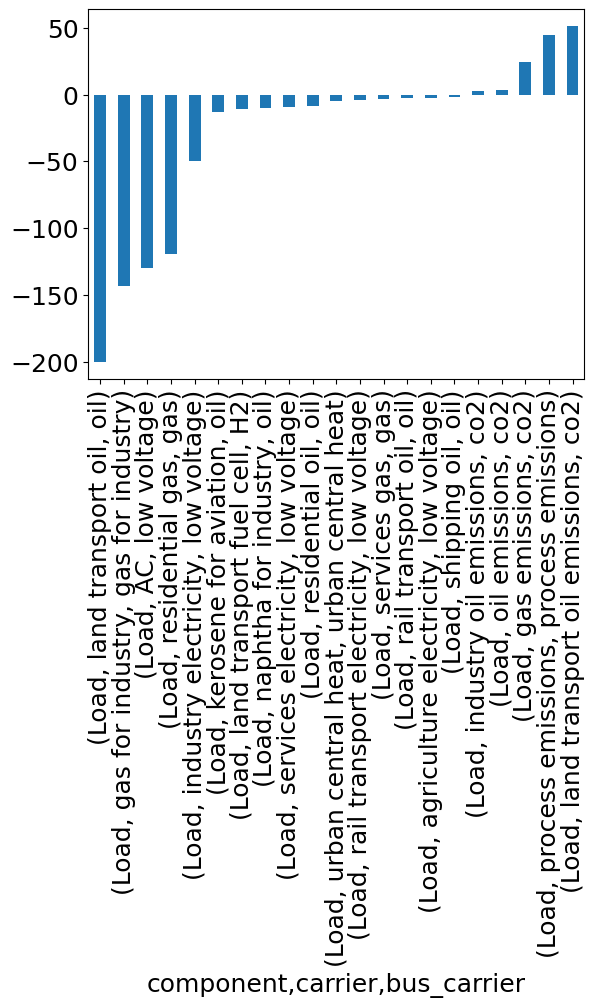

In [59]:
(load_stats[load_stats.abs() >= 1000000].sort_values(ascending=True) / 1e6).plot.bar()

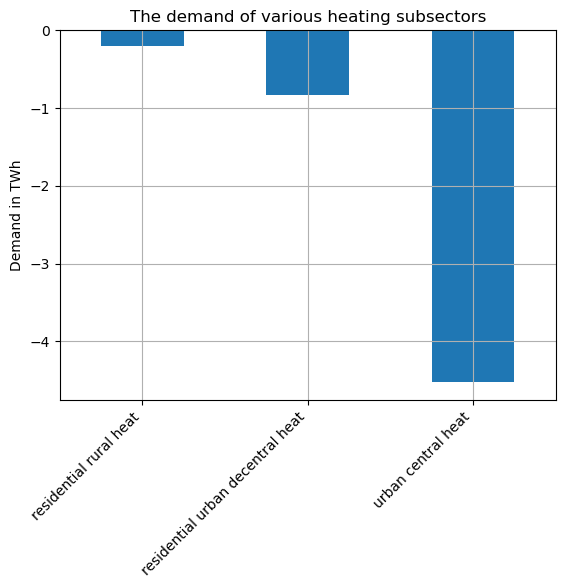

In [10]:
heating_stats_TWh = heating_stats_GWh/1000000

ax = heating_stats_TWh.plot.bar(
    title='The demand of various heating subsectors',
    xlabel="",
    ylabel="Demand in TWh"
)

ax.set_xticklabels(heating_stats_TWh.index.get_level_values('carrier'), rotation=45, ha="right")
ax.grid(True)
plt.show()

How is heating energy supplied (heat pump, district heating, resistive heater, gas boiler)

In [104]:
n.statistics.supply() / 1e6

component  carrier                                
Generator  Combined-Cycle Gas                         1.152567e-02
           Offshore Wind (AC)                         7.146699e-07
           Offshore Wind (DC)                         1.178988e-06
           Onshore Wind                               3.939953e-01
           Run of River                               8.766877e-02
                                                          ...     
Store      residential rural water tanks              6.954802e-09
           residential urban decentral water tanks    7.990415e-09
           services rural water tanks                 2.203123e-10
           services urban decentral water tanks       6.001557e-10
           urban central water tanks                  4.102936e-07
Length: 96, dtype: float64

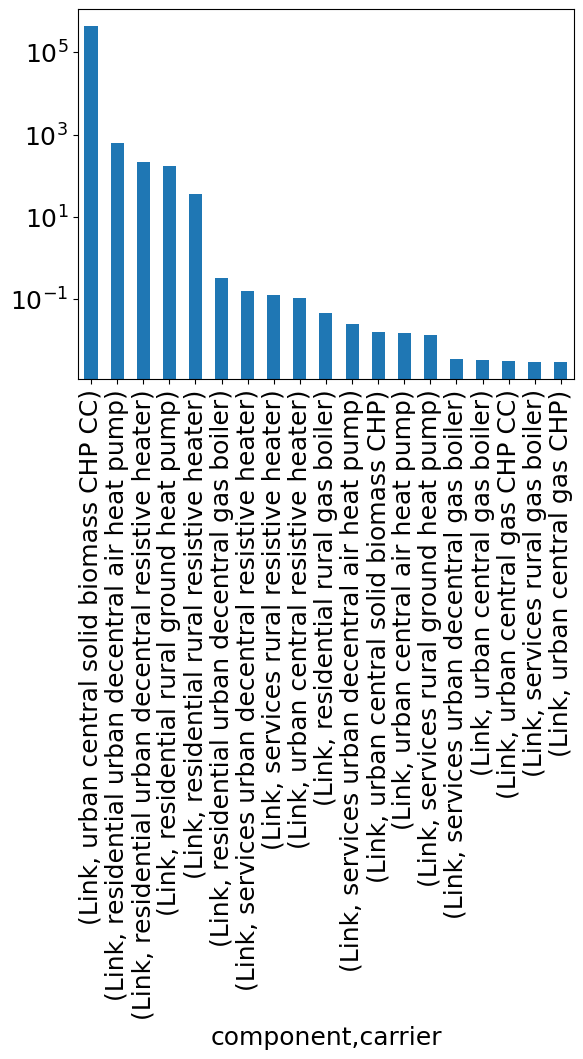

433.5139041924708

In [110]:
(n.statistics.supply(comps=["Link"]).loc[
    lambda x: x.index.get_level_values('carrier').str.contains('heat|boiler|pump|chp', case=False)
] / 1e3).sort_values(ascending=False).plot.bar()
plt.yscale('log')
plt.show()

(n.statistics.supply(comps=["Link"]).loc[
    lambda x: x.index.get_level_values('carrier').str.contains('heat|boiler|pump|chp', case=False)
] / 1e6).sum()

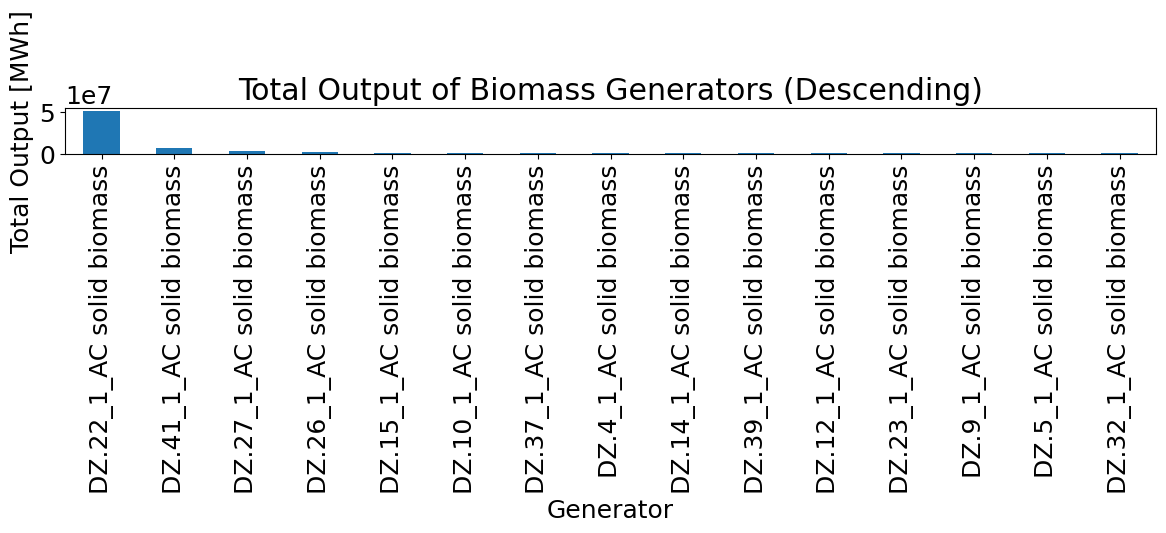

In [121]:
biomass_gens = n.generators[n.generators.carrier.str.contains("biomass", case=False)]
# Get the total output for each generator (sum over all snapshots)
biomass_output = n.generators_t.p[biomass_gens.index].sum()  # MWh
# Remove all outputs < 1e6 MWh
biomass_output = biomass_output[biomass_output >= 1e6]
biomass_output_sorted = biomass_output.sort_values(ascending=False)

plt.figure(figsize=(12, 5))
biomass_output_sorted.plot.bar()
plt.ylabel("Total Output [MWh]")
plt.title("Total Output of Biomass Generators (Descending)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Gas Boiler: 0.00037285823897161013 TWh
Heat Pump: 0.7852020136547986 TWh
Resistive Heater: 0.25000294767482323 TWh
CHP: 432.4783263729022 TWh


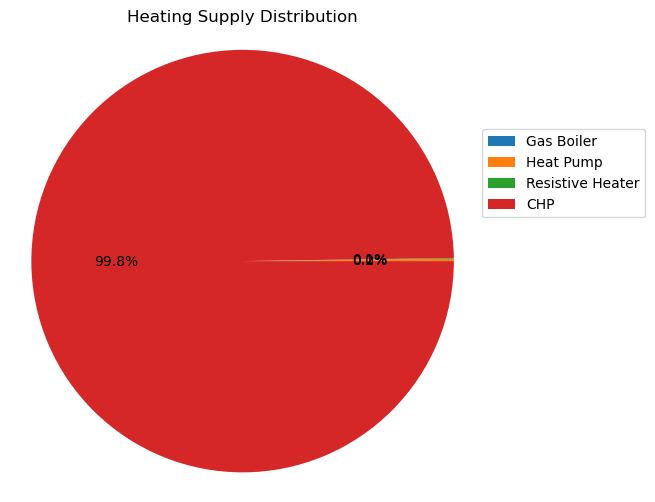

In [ ]:
heating_supply_stats = n.statistics.supply(comps=["Link"], aggregate_time="sum").loc[
    lambda x: x.index.get_level_values('carrier').str.contains('heat|boiler|pump|chp', case=False)
]

# Only the Gas boiler, heat pump, CHP, and resistive heater technologies are considered here
heating_types = ['Gas Boiler', 'Heat Pump', 'Resistive Heater', 'CHP']
heating_sums = [heating_supply_stats[heating_supply_stats.index.get_level_values('carrier').str.contains(heatingtype, case=False)].sum() for heatingtype in heating_types]

# ALternative: Save as dict

heating_sums_dict = {
    heating_type: heating_supply_stats.loc[
        heating_supply_stats.index.get_level_values('carrier').str.contains(heating_type, case=False)
    ].sum()
    for heating_type in heating_types
}

for ht, sum_value in zip(heating_types, heating_sums):
    print(f"{ht}: {sum_value/1e6} TWh")

plt.figure(figsize=(6, 6))
plt.pie(heating_sums, autopct='%1.1f%%')
plt.title('Heating Supply Distribution')
plt.legend(heating_types, loc='upper left', bbox_to_anchor=(1, 0.8))
plt.axis('equal')
plt.show()

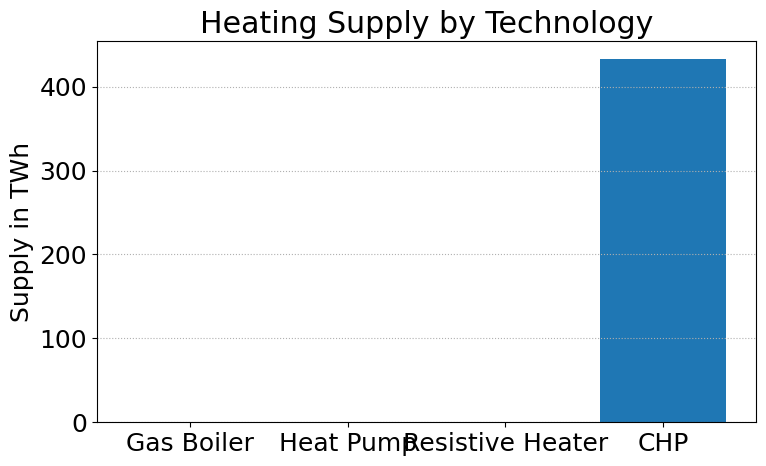

In [99]:
plt.figure(figsize=(8, 5))
plt.bar(heating_sums_dict.keys(), [v / 1e6 for v in heating_sums_dict.values()])
plt.ylabel('Supply in TWh')
plt.title('Heating Supply by Technology')
plt.grid(axis='y', linestyle='dotted')
plt.tight_layout()
plt.show()

In [98]:
# To get the energy balance for 'load', filter after calling energy_balance()
energy_balance = n.statistics.energy_balance()
# Exclude entries where bus_carrier is 'co2' and use absolute values
filtered = energy_balance[
    (energy_balance.index.get_level_values('component') == 'Load') &
    (energy_balance.index.get_level_values('bus_carrier') != 'co2')
].abs().sort_values(ascending=False) / 1e6
filtered

component  carrier                           bus_carrier                     
Load       land transport oil                oil                                 200.505315
           gas for industry                  gas for industry                    143.536383
           AC                                low voltage                         129.989627
           residential gas                   gas                                 119.367393
           industry electricity              low voltage                          50.084444
           process emissions                 process emissions                    44.310079
           kerosene for aviation             oil                                  12.882138
           land transport fuel cell          H2                                   10.587739
           naphtha for industry              oil                                  10.345532
           services electricity              low voltage                           9.558100
  

In [ ]:
chp_links = n.links[n.links.carrier.str.contains('chp', case=False, na=False)]
print(chp_links)

Link
DZ.10_1_AC co2 vent            co2 vent
DZ.11_1_AC co2 vent            co2 vent
DZ.12_1_AC co2 vent            co2 vent
DZ.13_1_AC co2 vent            co2 vent
DZ.14_1_AC co2 vent            co2 vent
                                 ...   
DZ.7_1_AC urban central DAC         DAC
DZ.8_1_AC urban central DAC         DAC
DZ.9_1_AC urban central DAC         DAC
DZ.4_1_AC H2 export                  H2
DZ.32_1_AC H2 export                 H2
Name: carrier, Length: 3128, dtype: object

In [ ]:
# Show all carrier entries with 'heat' in them using n.links_t

heat_link_mask = n.links.carrier.str.contains('heat', case=False, na=False)
heat_links = n.links[heat_link_mask].index

# Show demand (input power, p0) for those links, summed over all snapshots
heat_links_demand = ((n.links_t.p0[heat_links])*144).sum()  # MWh
heat_links_demand.sum() / 1e6



25.356117690049537

### Electricity Sector 
The share of different carriers (capacity and energy)

In [12]:
def color_matching(stats):
    colors = {key.lower(): value.lower() for key, value in config["plotting"]["tech_colors"].items()}
    nice_names = {value.lower(): key for key, value in config["plotting"]["nice_names"].items()}
    color_list = []
    for carrier in stats.index.get_level_values("carrier"):
        original_name = carrier.lower()
        key_name = nice_names.get(original_name, original_name)
        color = colors.get(key_name.lower(), 'gray')
        color_list.append(color)
    return color_list

In [13]:
capacity_stats = n.statistics.installed_capacity(comps=["Generator"])
# Remove carrier with the capacity = 0
capacity_stats_non_zero = capacity_stats[capacity_stats != 0].dropna()
capacity_stats_plus = n.statistics.installed_capacity(comps=["StorageUnit"])
combined_capacity_stats = pd.concat([capacity_stats_non_zero, capacity_stats_plus])
# Remove loads from the capacity stats
combined_capacity_stats = combined_capacity_stats.drop(('Generator', 'load'), errors='ignore')
combined_capacity_stats

component    carrier           
Generator    Combined-Cycle Gas    25886.371466
             Onshore Wind              9.506088
             Run of River             21.377915
             Solar                   425.800000
StorageUnit  Reservoir & Dam         100.000000
Name: p_nom, dtype: float64

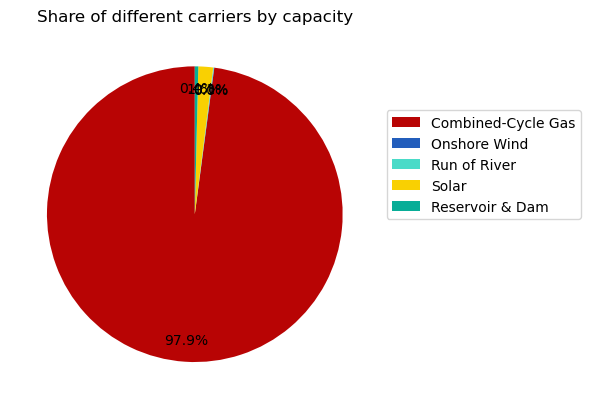

In [14]:
color_list = color_matching(combined_capacity_stats)

combined_capacity_stats.plot.pie(
    title="Share of different carriers by capacity",
    labels=None,
    autopct='%1.1f%%',
    pctdistance=0.85,
    startangle=90,
    ylabel="",
    colors=color_list,
)

custom_labels = combined_capacity_stats.index.get_level_values("carrier")
plt.legend(custom_labels, loc='upper left', bbox_to_anchor=(1, 0.8))


In [15]:
energy_stats = n.statistics.energy_balance(comps=["Generator"])
electricity_energy_stats = energy_stats[energy_stats.index.get_level_values('bus_carrier') == 'AC']
electricity_energy_stats_plus = n.statistics.energy_balance(comps=["StorageUnit"])
combined_electricity_energy_stats = pd.concat([electricity_energy_stats, electricity_energy_stats_plus])
# Remove load from the electricity geneation stats
combined_electricity_energy_stats = combined_electricity_energy_stats.drop(('Generator', 'load', 'AC'), errors='ignore')
combined_electricity_energy_stats

component    carrier             bus_carrier
Generator    Combined-Cycle Gas  AC             1.152567e+04
             Offshore Wind (AC)  AC             7.146699e-01
             Offshore Wind (DC)  AC             1.178988e+00
             Onshore Wind        AC             3.939953e+05
             Run of River        AC             8.766877e+04
             Solar               AC             1.212866e+09
StorageUnit  Reservoir & Dam     AC             1.618649e+05
dtype: float64

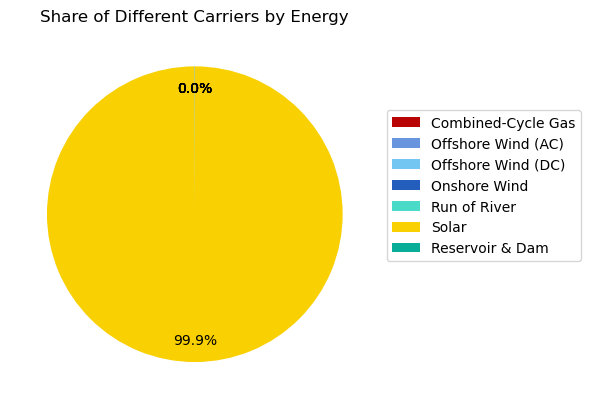

In [16]:
color_list = color_matching(combined_electricity_energy_stats)

combined_electricity_energy_stats.plot.pie(
    title='Share of Different Carriers by Energy',
    labels=None,
    autopct='%1.1f%%',
    pctdistance=0.85,
    startangle=90,
    ylabel="",
    colors=color_list,  
)

custom_labels = combined_electricity_energy_stats.index.get_level_values("carrier")
plt.legend(custom_labels, loc='upper left', bbox_to_anchor=(1, 0.8))

## Own investigation

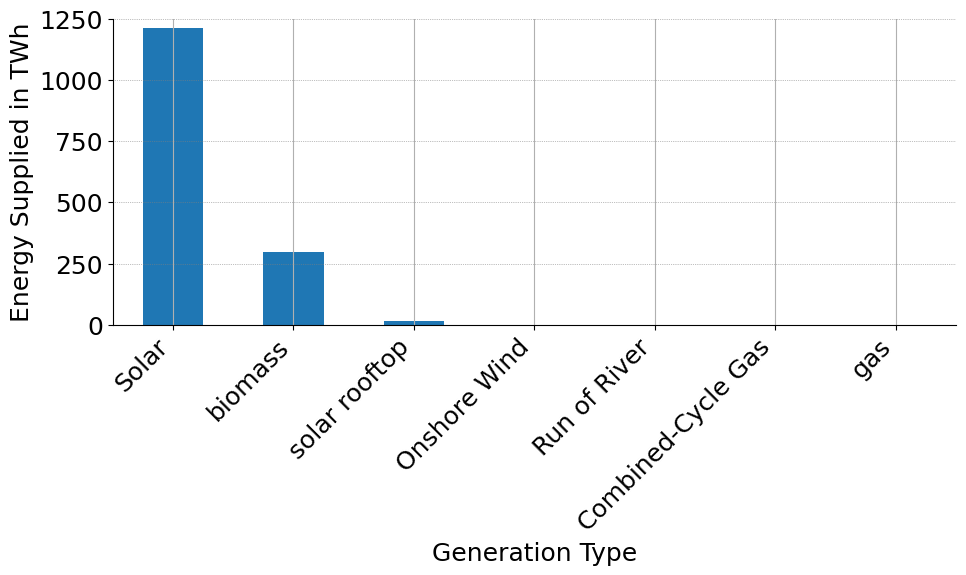

In [31]:
n.statistics()

# Plot all generator's supply
gen_supply = n.statistics.energy_balance(comps=["Generator"], aggregate_time="sum")
# Filter out zero or negative values if needed
gen_supply = gen_supply[gen_supply > 0]
# Filter out carriers < 10 MWh 
gen_supply = gen_supply[gen_supply > 10]
# Remove all 'load' from the index before plotting
gen_supply = gen_supply[gen_supply.index.get_level_values('carrier') != 'load']

# Sort by amount descending
gen_supply = gen_supply.sort_values(ascending=False)

# Plot
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots(figsize=(10, 6))
ax = (gen_supply / 1e6).plot.bar(
    # title="Total Supply by Generation Type",
    ylabel="Energy Supplied in TWh",
    xlabel="Generation Type"
)
# Hide the top and right frame lines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# Add dotted horizontal lines at all y ticks
plt.gca().yaxis.grid(True, linestyle='dotted', linewidth=0.5, color='gray')
#for y in plt.gca().get_yticks():
#    plt.axhline(y=y, color='gray', linestyle='dotted', linewidth=0.5)
# Limit the y-axis to 300 TWh
plt.ylim(0, 1250)
ax.set_xticklabels(gen_supply.index.get_level_values('carrier'), rotation=45, ha="right")
ax.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2258/3409129421.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


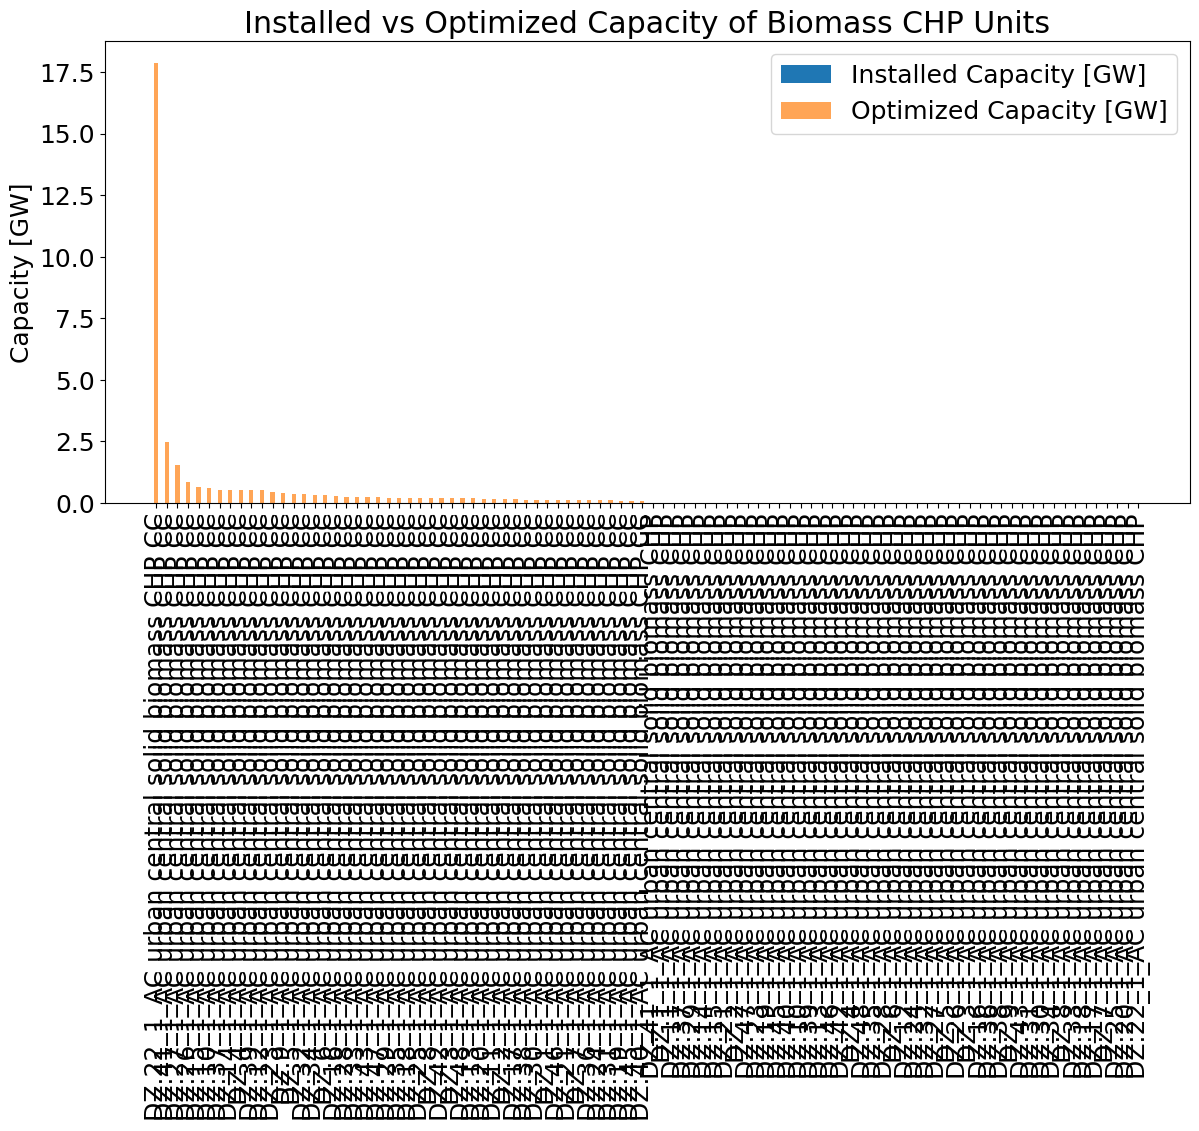

In [124]:
# Filter for biomass CHP units in chp_links
biomass_chp_mask = chp_links['carrier'].str.contains('biomass', case=False, na=False)
biomass_chp = chp_links[biomass_chp_mask]

# Get both Installed Capacity and Optimal Capacity
installed_capacity = biomass_chp['p_nom']
optimized_capacity = biomass_chp['p_nom_opt']

# Sort by optimized capacity descending
sorted_idx = optimized_capacity.sort_values(ascending=False).index

plt.figure(figsize=(14, 6))
plt.bar(biomass_chp.loc[sorted_idx].index, installed_capacity.loc[sorted_idx] / 1e3, width=0.4, label='Installed Capacity [GW]')
plt.bar(biomass_chp.loc[sorted_idx].index, optimized_capacity.loc[sorted_idx] / 1e3, width=0.4, label='Optimized Capacity [GW]', alpha=0.7)
plt.ylabel('Capacity [GW]')
plt.title('Installed vs Optimized Capacity of Biomass CHP Units')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

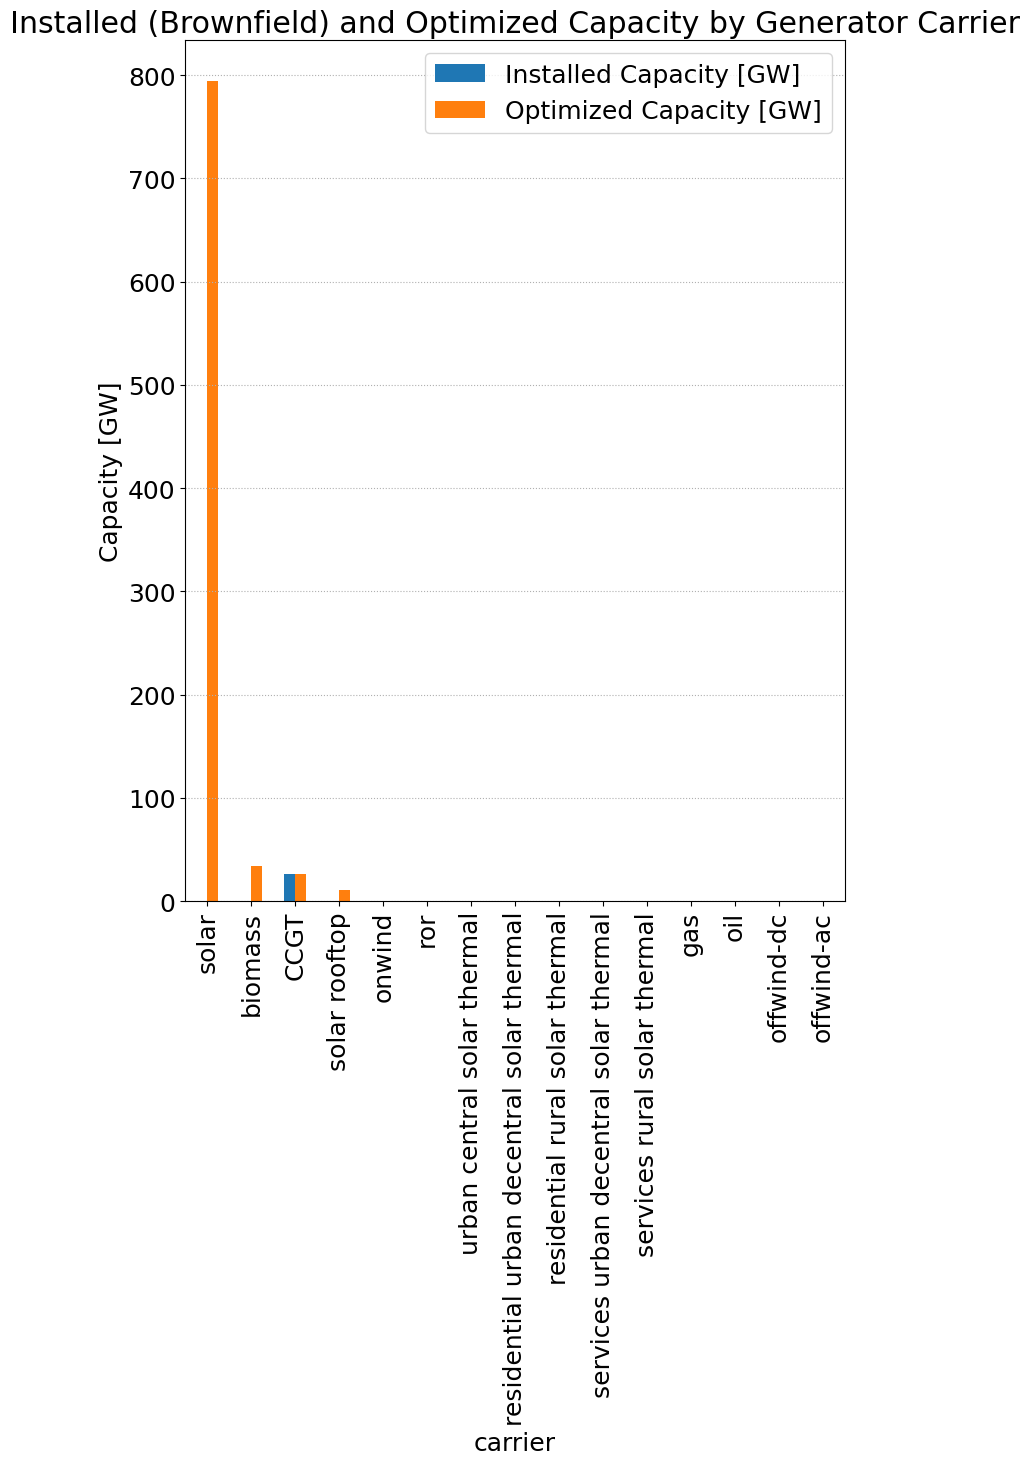

In [130]:
# Get all generators' installed and optimized capacities, grouped by carrier
installed_by_carrier = n.generators.groupby('carrier')['p_nom'].sum()
optimized_by_carrier = n.generators.groupby('carrier')['p_nom_opt'].sum()

# Combine into a DataFrame for plotting (convert to GW)
capacity_df = pd.DataFrame({
    'Installed Capacity [GW]': installed_by_carrier / 1e3,
    'Optimized Capacity [GW]': optimized_by_carrier / 1e3
})

# Remove 'load' and carriers with zero capacity
capacity_df = capacity_df.drop('load', errors='ignore')
capacity_df = capacity_df[(capacity_df > 0).any(axis=1)]

# Sort descending by optimized capacity
capacity_df = capacity_df.sort_values('Optimized Capacity [GW]', ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(8, 15))

capacity_df.plot.bar(ax=ax)
plt.ylabel('Capacity [GW]')
plt.title('Installed (Brownfield) and Optimized Capacity by Generator Carrier')
plt.grid(axis='y', linestyle='dotted')
plt.tight_layout()
plt.show()


In [ ]:
biomass_chp_buses = biomass_chp['bus0'].unique()
links_connected = n.links[
    n.links['bus0'].isin(biomass_chp_buses) | n.links['bus1'].isin(biomass_chp_buses)
]
links_connected

,bus0,bus1,carrier,p_nom_extendable,efficiency,capital_cost,bus2,bus3,bus4,efficiency2,...,start_up_cost,shut_down_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down
Link,,,,,,,,,,,,,,,,,,,,,
DZ.10_1_AC biomass,DZ.10_1_AC solid biomass,DZ.10_1_AC,biomass,False,0.468,137686.091948,co2 atmosphere,,,0.000000,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ.11_1_AC biomass,DZ.11_1_AC solid biomass,DZ.11_1_AC,biomass,False,0.468,137686.091948,co2 atmosphere,,,0.000000,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ.12_1_AC biomass,DZ.12_1_AC solid biomass,DZ.12_1_AC,biomass,False,0.468,137686.091948,co2 atmosphere,,,0.000000,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ.13_1_AC biomass,DZ.13_1_AC solid biomass,DZ.13_1_AC,biomass,False,0.468,137686.091948,co2 atmosphere,,,0.000000,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ.14_1_AC biomass,DZ.14_1_AC solid biomass,DZ.14_1_AC,biomass,False,0.468,137686.091948,co2 atmosphere,,,0.000000,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DZ.5_1_AC solid biomass for industry CC,DZ.5_1_AC solid biomass,DZ.5_1_AC solid biomass for industry,solid biomass for industry CC,True,0.900,76441.889997,co2 atmosphere,DZ.5_1_AC co2 stored,,-0.348365,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ.6_1_AC solid biomass for industry CC,DZ.6_1_AC solid biomass,DZ.6_1_AC solid biomass for industry,solid biomass for industry CC,True,0.900,76441.889997,co2 atmosphere,DZ.6_1_AC co2 stored,,-0.348365,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ.7_1_AC solid biomass for industry CC,DZ.7_1_AC solid biomass,DZ.7_1_AC solid biomass for industry,solid biomass for industry CC,True,0.900,76441.889997,co2 atmosphere,DZ.7_1_AC co2 stored,,-0.348365,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0


In [140]:
# Find all components (links, generators, stores, loads, etc.) connected to 'DZ.22_1_AC solid biomass bua'
bus_name = 'DZ.22_1_AC solid biomass'

connected = {}

# Links
links_connected = n.links[
    (n.links['bus0'] == bus_name) |
    (n.links['bus1'] == bus_name) |
    (n.links.get('bus2', pd.Series([None]*len(n.links))) == bus_name) |
    (n.links.get('bus3', pd.Series([None]*len(n.links))) == bus_name) |
    (n.links.get('bus4', pd.Series([None]*len(n.links))) == bus_name)
]
if not links_connected.empty:
    connected['links'] = links_connected

# Generators
generators_connected = n.generators[n.generators['bus'] == bus_name]
if not generators_connected.empty:
    connected['generators'] = generators_connected

# Stores
stores_connected = n.stores[n.stores['bus'] == bus_name]
if not stores_connected.empty:
    connected['stores'] = stores_connected

# Loads
loads_connected = n.loads[n.loads['bus'] == bus_name]
if not loads_connected.empty:
    connected['loads'] = loads_connected

# StorageUnits
if hasattr(n, 'storage_units'):
    storage_units_connected = n.storage_units[n.storage_units['bus'] == bus_name]
    if not storage_units_connected.empty:
        connected['storage_units'] = storage_units_connected

# Print results
for comp, df in connected.items():
    print(f"\n{comp.upper()} connected to {bus_name}:")
    display(df)


LINKS connected to DZ.22_1_AC solid biomass:


,bus0,bus1,carrier,p_nom_extendable,efficiency,capital_cost,bus2,bus3,bus4,efficiency2,...,start_up_cost,shut_down_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down
Link,,,,,,,,,,,,,,,,,,,,,
DZ.22_1_AC biomass,DZ.22_1_AC solid biomass,DZ.22_1_AC,biomass,False,0.468000,137686.091948,co2 atmosphere,,,0.000000,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ.22_1_AC biomass EOP,DZ.22_1_AC solid biomass,DZ.22_1_AC,biomass EOP,True,0.300300,112146.340640,,,,1.000000,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
biomass transport DZ.22_1_AC <-> DZ.33_1_AC,DZ.22_1_AC solid biomass,DZ.33_1_AC solid biomass,solid biomass transport,True,1.000000,37.392888,,,,1.000000,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
biomass transport DZ.33_1_AC <-> DZ.22_1_AC,DZ.33_1_AC solid biomass,DZ.22_1_AC solid biomass,solid biomass transport,True,1.000000,35.811781,,,,1.000000,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ.22_1_AC urban central solid biomass CHP,DZ.22_1_AC solid biomass,DZ.22_1_AC,urban central solid biomass CHP,True,0.265200,101259.297497,DZ.22_1_AC urban central heat,,,0.829400,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ.22_1_AC urban central solid biomass CHP CC,DZ.22_1_AC solid biomass,DZ.22_1_AC,urban central solid biomass CHP CC,True,0.230363,186194.730827,DZ.22_1_AC urban central heat,co2 atmosphere,DZ.22_1_AC co2 stored,0.877071,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ.22_1_AC solid biomass for industry,DZ.22_1_AC solid biomass,DZ.22_1_AC solid biomass for industry,solid biomass for industry,True,1.000000,0.000000,,,,1.000000,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ.22_1_AC solid biomass for industry CC,DZ.22_1_AC solid biomass,DZ.22_1_AC solid biomass for industry,solid biomass for industry CC,True,0.900000,76441.889997,co2 atmosphere,DZ.22_1_AC co2 stored,,-0.348365,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0



GENERATORS connected to DZ.22_1_AC solid biomass:


,carrier,bus,p_nom_min,p_nom,p_nom_extendable,efficiency,marginal_cost,capital_cost,p_nom_max,weight,...,shut_down_cost,stand_by_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down
Generator,,,,,,,,,,,,,,,,,,,,,
DZ.22_1_AC solid biomass,biomass,DZ.22_1_AC solid biomass,0.0,0.000000e+00,True,1.0,7.417711,0.0,inf,1.0,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ.22_1_AC solid biomass load,load,DZ.22_1_AC solid biomass,0.0,1.000000e+12,False,1.0,1000.010285,0.0,inf,1.0,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0



STORES connected to DZ.22_1_AC solid biomass:


,bus,carrier,e_nom_extendable,e_cyclic,capital_cost,e_initial,e_min_pu,e_nom,lifetime,marginal_cost,...,e_nom_min,e_nom_max,e_max_pu,e_initial_per_period,e_cyclic_per_period,p_set,q_set,sign,marginal_cost_quadratic,build_year
Store,,,,,,,,,,,,,,,,,,,,,
DZ.22_1_AC solid biomass Store,DZ.22_1_AC solid biomass,biomass,True,True,0.0,0.0,0.0,0.0,inf,0.009564,...,0.0,inf,1.0,False,True,0.0,0.0,1.0,0.0,0
DZ.22_1_AC solid biomass,DZ.22_1_AC solid biomass,solid biomass,False,False,0.0,0.0,0.0,0.0,inf,13.659646,...,0.0,inf,1.0,False,True,0.0,0.0,1.0,0.0,0



LOADS connected to DZ.22_1_AC solid biomass:


,bus,carrier,p_set,type,q_set,sign
Load,,,,,,
DZ.22_1_AC residential biomass,DZ.22_1_AC solid biomass,residential biomass,0.0,,0.0,-1.0
DZ.22_1_AC services biomass,DZ.22_1_AC solid biomass,services biomass,0.0,,0.0,-1.0


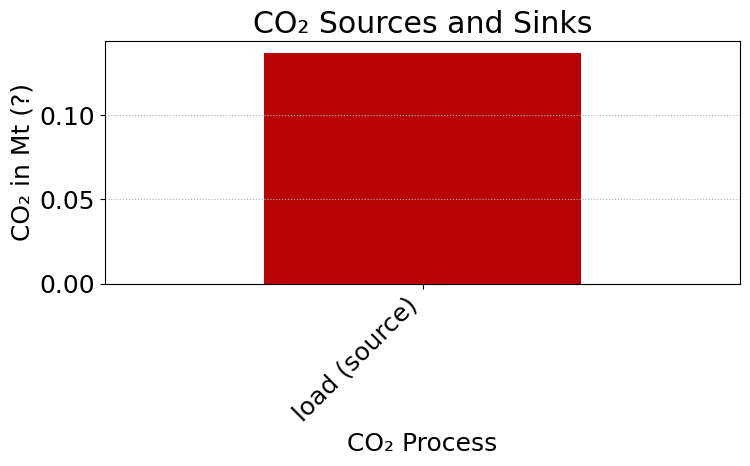

In [18]:
# Filter for CO2 sources and sinks in the energy_stats
co2_stats = energy_stats[energy_stats.index.get_level_values('bus_carrier').str.contains('co2', case=False)]

# Separate sources (positive values) and sinks (negative values)
co2_sources = co2_stats[co2_stats > 0]
co2_sinks = co2_stats[co2_stats < 0]

# Combine for plotting
co2_plot = pd.concat([co2_sources, co2_sinks])

# Prepare labels for the plot
labels = [
    f"{idx[1]} ({'source' if val > 0 else 'sink'})"
    for idx, val in co2_plot.items()
]

plt.figure(figsize=(8, 5))
(co2_plot).plot.bar(
    color=['#b80404' if val > 0 else '#4adbc8' for val in co2_plot],
    ylabel="CO₂ in Mt (?)",
    xlabel="CO₂ Process",
    title="CO₂ Sources and Sinks"
)
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45, ha="right")
plt.tight_layout()
plt.grid(axis='y', linestyle='dotted')
plt.show()

In [19]:
energy_stats

component  carrier                                    bus_carrier                            
Generator  Combined-Cycle Gas                         AC                                         1.152567e+04
           Offshore Wind (AC)                         AC                                         7.146699e-01
           Offshore Wind (DC)                         AC                                         1.178988e+00
           Onshore Wind                               AC                                         3.939953e+05
           Run of River                               AC                                         8.766877e+04
           Solar                                      AC                                         1.212866e+09
           biomass                                    biomass                                    2.973659e+08
           gas                                        gas                                        1.624726e+01
           load           

In [20]:
stats = n.statistics()
# Extract co2 entries from the statistics
co2_entries = stats.loc[stats.index.to_frame().astype(str).apply(lambda row: row.str.contains('co2', case=False).any(), axis=1)]
#print(co2_entries)

co2_stored = co2_entries.loc[('Store', 'co2 stored')].Withdrawal

print("The total amount of CO2 stored in the system is: {:.2f} Mt".format(co2_stored / 1e6))

# To access the Capital Expenditure for ('Store', 'co2 stored'), use:
co2_entries.loc[('Store', 'co2 stored'), 'Capital Expenditure'] / 1e6

The total amount of CO2 stored in the system is: 4.81 Mt


20.502354228475507

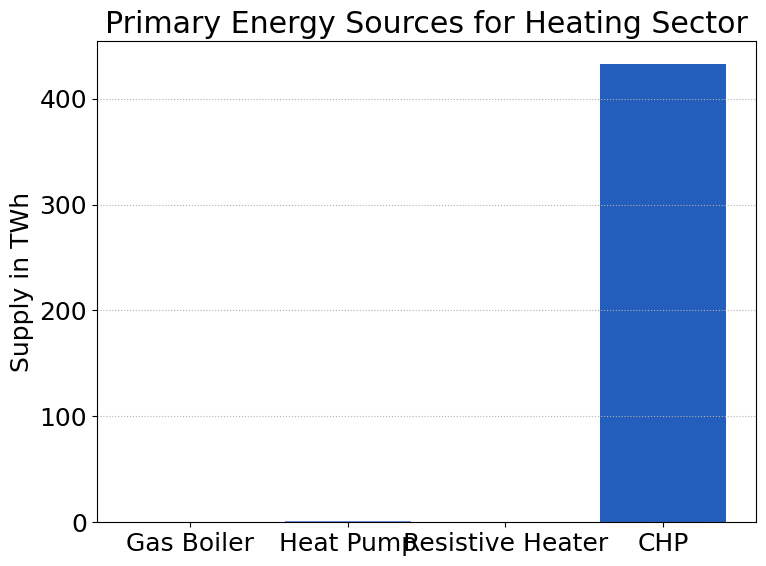

In [21]:
# Plot the primary energy sources for the heating sector
# We'll use heating_supply_stats and heating_types from previous cells

plt.figure(figsize=(8, 6))
plt.bar(heating_types, [v / 1e6 for v in heating_sums], color=['#b80404', '#6895dd', '#74c6f2', '#235ebc'])
plt.ylabel('Supply in TWh')
plt.title('Primary Energy Sources for Heating Sector')
plt.grid(axis='y', linestyle='dotted')
plt.tight_layout()
plt.show()

In [22]:
# Extract all CHP units from n.links_t
# The primary energy carrier is in n.links.carrier, and the volume is in n.links_t.p0 (input power)
chp_mask = n.links.carrier.str.contains('chp', case=False, na=False)
chp_links = n.links[chp_mask]

# For each CHP, get its name, primary energy carrier, and total input volume (sum over all snapshots)
chp_volumes = n.links_t.p0[chp_links.index].sum() * 144
chp_info = pd.DataFrame({
    "Primary Carrier": chp_links.bus0,
    "Volume (MWh)": chp_volumes
}).reset_index()

print(chp_info)

chp_volumes.sum() / 1e6

                                             Link          Primary Carrier  \
0                DZ.10_1_AC urban central gas CHP           DZ.10_1_AC gas   
1                DZ.11_1_AC urban central gas CHP           DZ.11_1_AC gas   
2                DZ.12_1_AC urban central gas CHP           DZ.12_1_AC gas   
3                DZ.13_1_AC urban central gas CHP           DZ.13_1_AC gas   
4                DZ.14_1_AC urban central gas CHP           DZ.14_1_AC gas   
..                                            ...                      ...   
183  DZ.5_1_AC urban central solid biomass CHP CC  DZ.5_1_AC solid biomass   
184  DZ.6_1_AC urban central solid biomass CHP CC  DZ.6_1_AC solid biomass   
185  DZ.7_1_AC urban central solid biomass CHP CC  DZ.7_1_AC solid biomass   
186  DZ.8_1_AC urban central solid biomass CHP CC  DZ.8_1_AC solid biomass   
187  DZ.9_1_AC urban central solid biomass CHP CC  DZ.9_1_AC solid biomass   

     Volume (MWh)  
0    2.687690e+00  
1    2.688008e+00  
2  

14259.49110761251

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (2,) and arg 1 with shape (47,).

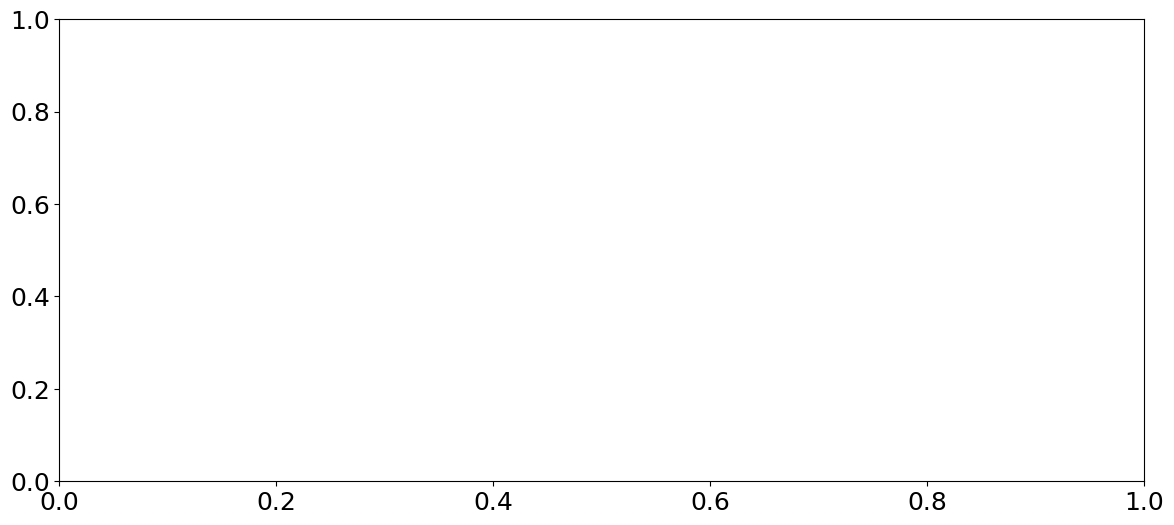

In [23]:
import numpy as np

# Show p0 and p1 for each CHP unit
# Calculate total input (p0) and output (p1) for each CHP unit
chp_p0_p1 = []
for chp in chp_links.index:
    p0 = n.links_t.p0[chp].sum() * 144  # Total input power over all snapshots
    p1 = n.links_t.p1[chp].sum() * 144  # Total output power over all snapshots
    chp_p0_p1.append((chp, p0, p1))

# Sort by p0 descending
chp_p0_p1_sorted = sorted(chp_p0_p1, key=lambda x: x[1], reverse=True)

# Filter out CHPs with p0 < 10 GWh
chp_p0_p1_sorted = [item for item in chp_p0_p1_sorted if item[1] >= 1e6]

# Prepare data for plotting
# labels = [chp for chp, p0, p1 in chp_p0_p1_sorted]
labels = ['DZ41.1', 'DZ1.1']
p0_values = [p0 / 1e6 for chp, p0, p1 in chp_p0_p1_sorted]  # TWh
p1_values = [abs(p1) / 1e6 for chp, p0, p1 in chp_p0_p1_sorted]  # TWh, absolute values

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, p0_values, width, label='Input Power (p0) [TWh]')
ax.bar(x + width/2, p1_values, width, label='Output Power (p1) [TWh]')
plt.xticks(x, labels, rotation=45)
plt.ylabel('Energy [TWh]')
plt.title('CHP Units: Input (p0) and Output (p1) Energy (Descending by p0)')
plt.legend()
plt.tight_layout()
plt.show()